In [17]:
import seaborn as sns

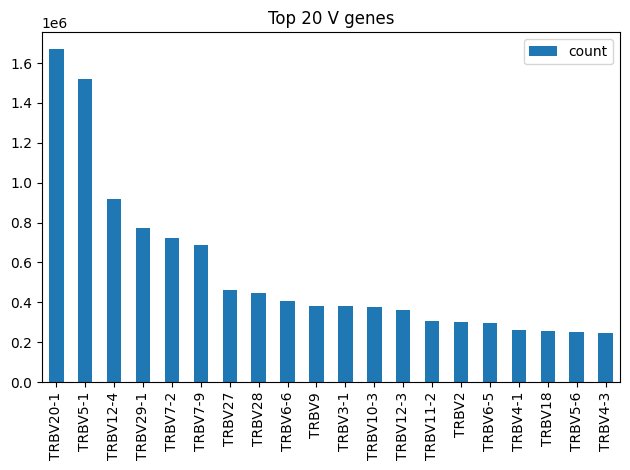

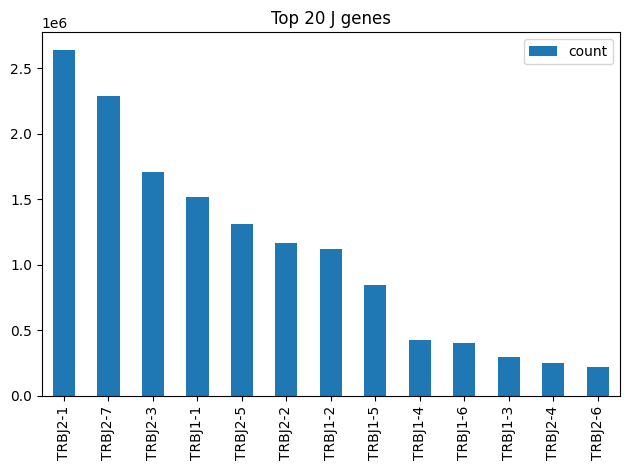

In [27]:
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# Путь к директории
data_dir = Path("/projects/immunestatus/rheum/airr_format")

# Чтение метаданных
metadata = pd.read_csv(data_dir / "metadata.tsv", sep='\t')

# Подготовка контейнера для сбора статистики
summary_stats = []

# Словари для подсчёта всех V и J генов
v_counts = Counter()
j_counts = Counter()

# Обработка каждого файла
for sample_name in metadata["sample_name"]:
    file_path = data_dir / f"{sample_name}.tsv"
    if not file_path.exists():
        print(f"Файл не найден: {file_path}")
        continue

    df = pd.read_csv(file_path, sep='\t')
    total_clonotypes = len(df)
    total_reads = df["count"].sum()
    v_counts.update(df["v_call"])
    j_counts.update(df["j_call"])

    summary_stats.append({
        "sample_name": sample_name,
        "n_clonotypes": total_clonotypes,
        "total_reads": total_reads,
    })

# Сводная таблица по сэмплам
summary_df = pd.DataFrame(summary_stats)

# Представленность V и J генов по всем данным
v_df = pd.DataFrame.from_dict(v_counts, orient='index', columns=["count"]).sort_values("count", ascending=False)
j_df = pd.DataFrame.from_dict(j_counts, orient='index', columns=["count"]).sort_values("count", ascending=False)

# Сохранение результатов
summary_df.to_csv(data_dir / "summary_stats_by_sample.tsv", sep='\t', index=False)
v_df.to_csv(data_dir / "v_gene_usage.tsv", sep='\t')
j_df.to_csv(data_dir / "j_gene_usage.tsv", sep='\t')

# Быстрая визуализация
v_df.head(20).plot(kind='bar', title="Top 20 V genes")
plt.tight_layout()
plt.show()

j_df.head(20).plot(kind='bar', title="Top 20 J genes")
plt.tight_layout()
plt.show()


In [29]:
v_df.index

Index(['TRBV20-1', 'TRBV5-1', 'TRBV12-4', 'TRBV29-1', 'TRBV7-2', 'TRBV7-9',
       'TRBV27', 'TRBV28', 'TRBV6-6', 'TRBV9', 'TRBV3-1', 'TRBV10-3',
       'TRBV12-3', 'TRBV11-2', 'TRBV2', 'TRBV6-5', 'TRBV4-1', 'TRBV18',
       'TRBV5-6', 'TRBV4-3', 'TRBV7-8', 'TRBV15', 'TRBV24-1', 'TRBV4-2',
       'TRBV5-5', 'TRBV7-3', 'TRBV19', 'TRBV6-3', 'TRBV7-6', 'TRBV6-1',
       'TRBV25-1', 'TRBV30', 'TRBV6-2', 'TRBV21-1', 'TRBV14', 'TRBV5-4',
       'TRBV10-2', 'TRBV6-4', 'TRBV13', 'TRBV11-3', 'TRBV7-7', 'TRBV10-1',
       'TRBV12-5', 'TRBV11-1', 'TRBV5-8', 'TRBV23-1', 'TRBV16', 'TRBV7-4',
       'TRBV12-2', 'TRBV3-2', 'TRBV6-7', 'TRBV6-8', 'TRBV12-1', 'TRBV5-3',
       'TRBV6-9', 'TRBV7-1', 'TRBV1', 'TRBV5-7', 'TRBV7-5', 'TRBV5-2',
       'TRBV26', 'TRBV22-1', 'TRBV8-2', 'TRBV17'],
      dtype='object')

In [30]:
j_df.index

Index(['TRBJ2-1', 'TRBJ2-7', 'TRBJ2-3', 'TRBJ1-1', 'TRBJ2-5', 'TRBJ2-2',
       'TRBJ1-2', 'TRBJ1-5', 'TRBJ1-4', 'TRBJ1-6', 'TRBJ1-3', 'TRBJ2-4',
       'TRBJ2-6'],
      dtype='object')

<Axes: >

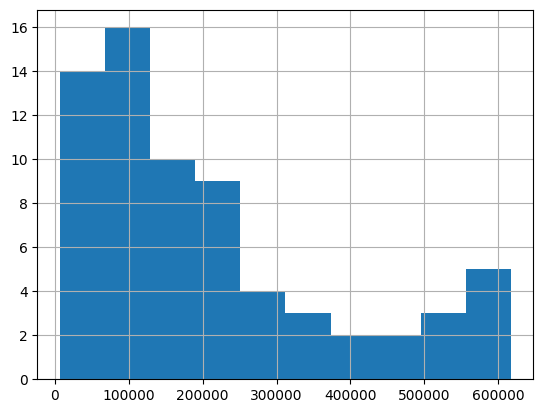

In [4]:
summary_df.n_clonotypes.hist()

In [5]:
summary_df.n_clonotypes

0     100577
1      92906
2      60109
3     395529
4      45983
       ...  
63     97706
64    135939
65     67812
66    128247
67     41604
Name: n_clonotypes, Length: 68, dtype: int64

In [10]:
metadata[metadata.disease_status == 'as'].sort_values(by='donor_id')

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
26,Abd,as,pos,NaN,PBMC,NaN,as_Abd_PB_F,bulk
27,Abr,as,pos,NaN,PBMC,NaN,as_Abr_PB_F,bulk
28,Ash-110,as,pos,NaN,PBMC,NaN,as_Ash-110_PB_F_p0,bulk
29,Ash-111,as,pos,NaN,PBMC,NaN,as_Ash-111_PB_F_p0,bulk
30,Bal,as,pos,NaN,PBMC,NaN,as_Bal_PB_F,bulk
31,Bel,as,pos,NaN,PBMC,NaN,as_Bel_PB_F,bulk
32,Bost,as,pos,NaN,PBMC,NaN,as_Bost_PB_F,bulk
33,Chaad,as,pos,NaN,PBMC,NaN,as_Chaad_PB_F,bulk
34,Dv,as,pos,NaN,PBMC,NaN,as_Dv_PB_CD8,cd8
35,Dv,as,pos,NaN,SF,NaN,as_Dv_SFCD8,cd8


In [11]:
metadata[metadata.disease_status != 'as'].sort_values(by='donor_id')

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction
23,Azh_0,hd,neg,NaN,NaN,NaN,Azh_0,NaN
19,DL_0,hd,neg,NaN,NaN,NaN,DL_0,NaN
22,KB_0,hd,neg,NaN,NaN,NaN,KB_0,NaN
24,KM,hd,neg,NaN,NaN,NaN,KM,NaN
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN
45,LK,hd,pos,NaN,PBMC,NaN,hd_LK_PB_F,bulk
46,LN,hd,pos,NaN,PBMC,NaN,hd_LN_PB_F,bulk
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN
52,OB,hd,pos,NaN,PBMC,NaN,hd_OB_PB_F,bulk
53,Sass,hd,pos,NaN,PBMC,NaN,hd_Sass_PB_F,bulk


In [12]:
metadata[metadata.disease_status != 'as'].donor_id.nunique()

33

In [13]:
metadata[metadata.disease_status != 'as'].b27.value_counts()

b27
neg    21
pos    12
Name: count, dtype: int64

<Axes: xlabel='disease_status', ylabel='n_clonotypes'>

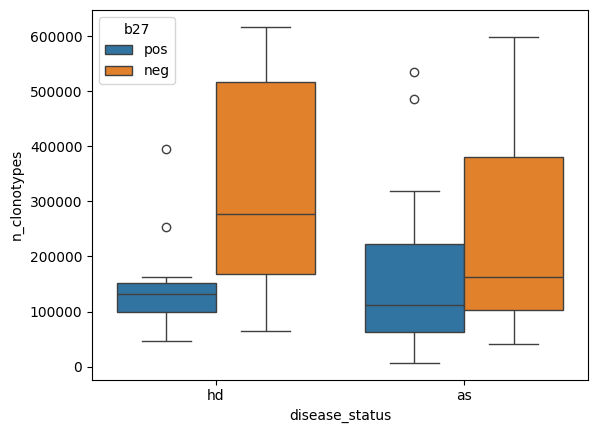

In [25]:
sns.boxplot(metadata.merge(summary_df), y='n_clonotypes', x='disease_status', hue='b27')

In [16]:
hd_meta = metadata[metadata.disease_status != 'as'].merge(summary_df)

<Axes: xlabel='b27', ylabel='n_clonotypes'>

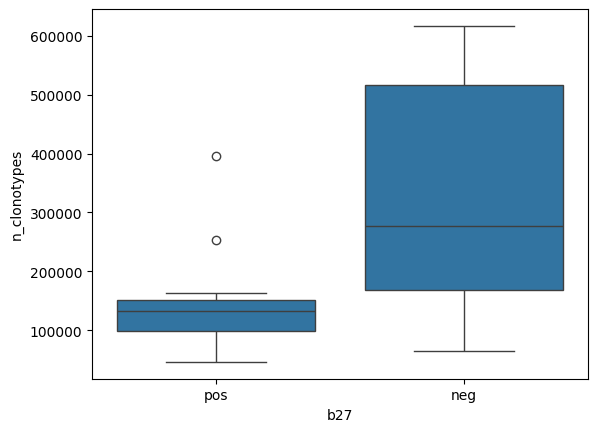

In [20]:
sns.boxplot(hd_meta, y='n_clonotypes', x='b27')

In [21]:
hd_meta

,donor_id,disease_status,b27,proj,sample_type,time_point,sample_name,fraction,n_clonotypes,total_reads
0,Koc,hd,pos,GCSF,PBMC,normal blood,Koc,NaN,100577,170106.0
1,Make,hd,pos,ch45,CD45RAdepleted PBMC,after G-CSFstim,Make,NaN,92906,500153.0
2,p144852,hd,pos,ch45-2,PBMC,after G-CSFstim,p144852,NaN,60109,90424.0
3,p1004,hd,pos,child_Leu,PBMC,after G-CSFstim,p1004,NaN,395529,676832.0
4,p112635,hd,pos,ch45-2,PBMC,after G-CSFstim,p112635,NaN,45983,54712.0
5,p434,hd,neg,child_Leu,PBMC,after G-CSFstim,p434,NaN,516011,743546.0
6,p556,hd,neg,child_Leu,PBMC,after G-CSFstim,p556,NaN,475266,663351.0
7,p744,hd,neg,child_Leu,PBMC,after G-CSFstim,p744,NaN,543261,957421.0
8,p754,hd,neg,child_Leu,PBMC,after G-CSFstim,p754,NaN,63848,167429.0
9,p1005,hd,neg,child_Leu,PBMC,after G-CSFstim,p1005,NaN,376043,685506.0
